# Summertime climatology turbulent air-sea fluxes

In [1]:
import intake
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt 
import calendar
import cmocean as cmo
from dask.distributed import Client
import cartopy.crs as ccrs
import cartopy.feature as cft
import matplotlib.ticker as mticker
from matplotlib.patches import Rectangle


from os import environ
environ["PYTHONWARNINGS"] = "ignore"

## Some (very specific) functions

In [2]:
def compute_climatologies(experiments, var_names, catalog, frequency, 
                          start_time, end_time, region_lat, region_lon):
    """
    Compute monthly climatologies for one or more variables across multiple experiments.

    Parameters
    ----------
    experiments : dict
        Mapping of resolution tags (e.g., '010', '025') to experiment names.
    var_names : str | list | dict
        Variable name(s) for each experiment:
        - Single string if all experiments use the same name.
        - List of names (must match order/length of experiments).
        - Dict keyed by resolution (e.g., {'010': 'sst', '025': 'temp', ...}).
    catalog : intake catalog
        Intake catalog containing the experiment datasets.
    frequency : str
        Frequency string used in the catalog search.
    start_time, end_time : str
        Time range for selection (e.g., '2000-01-01', '2010-12-31').
    region_lat, region_lon : list or tuple
        Latitude and longitude bounds [min, max] for selection.

    Returns
    -------
    dict
        Dictionary of xarray Datasets containing monthly climatologies for each resolution.
    """

    var_climatologies = {}

    # Convert list to dict if needed
    if isinstance(var_names, list):
        var_names = dict(zip(experiments.keys(), var_names))
    elif isinstance(var_names, str):
        var_names = {res: var_names for res in experiments.keys()}

    for res, expt_name in experiments.items():
        var = var_names[res]

        # Load dataset
        var_ds = catalog[expt_name].search(variable=var, frequency=frequency).to_dask()

        # Select time / lat / lon range
        var_ds = var_ds.sel(time=slice(start_time, end_time))
        var_ds = var_ds.sel(yt_ocean=slice(region_lat[0], region_lat[1]))
        var_ds = var_ds.sel(xt_ocean=slice(region_lon[0], region_lon[1]))

        # --- Compute climatology (monthly mean) ---
        var_clim = var_ds.groupby("time.month").mean("time")

        # Store processed climatology
        var_climatologies[res] = var_clim

    return var_climatologies

## Main code

In [3]:
client = Client(threads_per_worker=1)
client

/g/data/xp65/public/apps/med_conda/envs/analysis3-25.09/lib/python3.11/site-packages/distributed/node.py:187: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 45941 instead
  warnings.warn(


Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: /proxy/45941/status,
Dashboard: /proxy/45941/status,Workers: 28
Total threads: 28,Total memory: 126.00 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:39977,Workers: 0
Dashboard: /proxy/45941/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:40653,Total threads: 1
Dashboard: /proxy/43605/status,Memory: 4.50 GiB
Nanny: tcp://127.0.0.1:46203,


In [4]:
catalog = intake.cat.access_nri
#variables = catalog.search(name='025deg_jra55_iaf_omip2_cycle6', frequency = '1mon').unique().variable
#print(variables)

In [5]:
# --- common parameters
frequency = '1mon'
start_time = "1999-01-01"
end_time = "2018-12-31"

region_lat   = np.array([-56,-29])                    # yt_ocean,N
region_lon   = np.array([129,161]) 
region_lon   = region_lon - 360  

inset_lat   = np.array([-47.5,-46])                    # yt_ocean,N
inset_lon   = np.array([141.2,142.7]) 
inset_lon   = inset_lon - 360  

experiments = {
    "0.1": "01deg_jra55v140_iaf_cycle4",
    "0.25": "025deg_jra55_iaf_omip2_cycle6",
    "1.0": "1deg_jra55_iaf_omip2_cycle6",
}

In [6]:
# --- common plot features
# Land feature
land_50m = cft.NaturalEarthFeature( "physical", "land", "50m",
    edgecolor="black",linewidth=0.5)

# Projection
projection = ccrs.Mercator(central_longitude=145, min_latitude=-55, max_latitude=-29)

titles = [r"ACCESS-OM2 $1.0^\circ$", r"ACCESS-OM2 $0.25^\circ$", r"ACCESS-OM2 $0.1^\circ$"]

## Latent heat

In [7]:
# --- load / average data to produce monthly climatology
var_names = "evap_heat"
latent_climatologies = compute_climatologies(
    experiments = experiments,
    var_names = var_names,
    catalog = catalog,
    frequency = frequency,
    start_time = start_time,
    end_time = end_time,
    region_lat = region_lat,
    region_lon = region_lon,
)

/g/data/xp65/public/apps/med_conda/envs/analysis3-25.09/lib/python3.11/site-packages/intake_esm/core.py:321: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  records = grouped.get_group(internal_key).to_dict(orient='records')
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.09/lib/python3.11/site-packages/intake_esm/core.py:321: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  records = grouped.get_group(internal_key).to_dict(orient='records')
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.09/lib/python3.11/site-packages/intake_esm/core.py:321: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. 

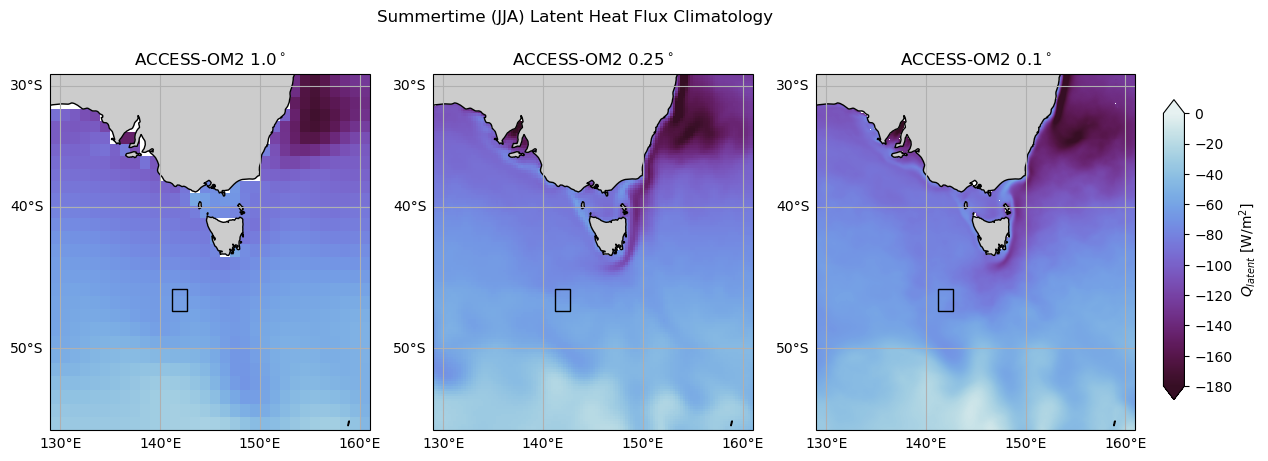

In [10]:
# --- wintertime latent heat
# Figure
fig, axes = plt.subplots(1, 3, figsize=(14, 5), subplot_kw={"projection": projection},)

latent010 = latent_climatologies['0.1']['evap_heat'].isel(month = [11, 0, 1]).mean(dim = 'month')
latent025 = latent_climatologies['0.25']['evap_heat'].isel(month = [11, 0, 1]).mean(dim = 'month')
latent100 = latent_climatologies['1.0']['evap_heat'].isel(month = [11, 0, 1]).mean(dim = 'month')

vmin = -180
vmax = 0

im0 = latent100.plot(ax = axes[0], transform=ccrs.PlateCarree(),
         vmin=vmin, vmax=vmax, cmap=cmo.cm.dense_r, add_colorbar=False)

im1 = latent025.plot(ax = axes[1], transform=ccrs.PlateCarree(),
         vmin=vmin, vmax=vmax, cmap=cmo.cm.dense_r, add_colorbar=False)

im2 = latent010.plot(ax = axes[2], transform=ccrs.PlateCarree(),
         vmin=vmin, vmax=vmax, cmap=cmo.cm.dense_r, add_colorbar=False)

cax = fig.add_axes([0.92, 0.2, 0.015, 0.6]) 
cbar = fig.colorbar(im2, cax=cax, orientation="vertical", label = r"$Q_{latent}$ [W/m$^2$]", 
                    fraction = 0.03, aspect = 15,  shrink = 0.9, extend = "both")

titles = [r"ACCESS-OM2 $1.0^\circ$", r"ACCESS-OM2 $0.25^\circ$", r"ACCESS-OM2 $0.1^\circ$"]

for ax, title in zip(axes, titles):

    ax.set_extent([129, 161, -55, -29], crs=ccrs.PlateCarree())
    ax.add_feature(land_50m, color=[0.8, 0.8, 0.8])
    ax.coastlines(resolution="50m")
    ax.gridlines(draw_labels={"bottom": True, "left": True, "top": False, "right": False},
                 xlocs=[130, 140, 150, 160], ylocs=[-30, -40, -50],)

    rect = Rectangle(
            (inset_lon.min(), inset_lat.min()),
            np.diff(inset_lon)[0], np.diff(inset_lat)[0],
            linewidth=1, edgecolor='k', facecolor='none', linestyle='-',
            zorder=5, transform=ccrs.PlateCarree(),
        )
    
    ax.add_patch(rect,)
    ax.set_title(title)

plt.suptitle('Summertime (JJA) Latent Heat Flux Climatology')
plt.savefig("Qlat_summer_3panel.png", dpi=300, bbox_inches="tight")
# plt.show()

## Sensible Heat

In [11]:
# --- load / average data to produce monthly climatology
var_names = "sens_heat"
sensible_climatologies = compute_climatologies(
    experiments = experiments,
    var_names = var_names,
    catalog = catalog,
    frequency = frequency,
    start_time = start_time,
    end_time = end_time,
    region_lat = region_lat,
    region_lon = region_lon,
)

/g/data/xp65/public/apps/med_conda/envs/analysis3-25.09/lib/python3.11/site-packages/intake_esm/core.py:321: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  records = grouped.get_group(internal_key).to_dict(orient='records')
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.09/lib/python3.11/site-packages/intake_esm/core.py:321: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  records = grouped.get_group(internal_key).to_dict(orient='records')
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.09/lib/python3.11/site-packages/intake_esm/core.py:321: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. 

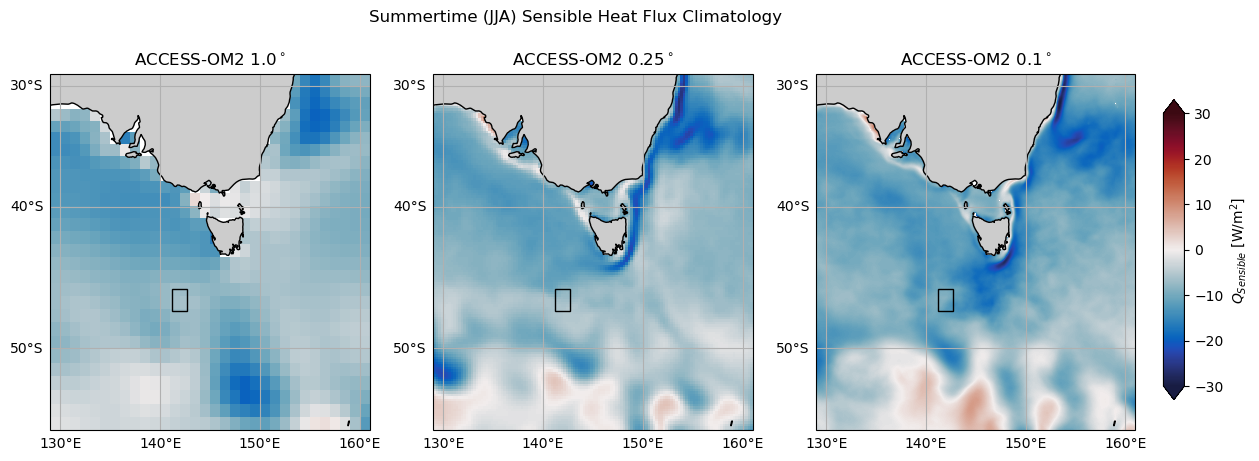

In [15]:
# --- wintertime sensible heat
# Figure
fig, axes = plt.subplots(1, 3, figsize=(14, 5), subplot_kw={"projection": projection},)

sensible010 = sensible_climatologies['0.1']['sens_heat'].isel(month = [11, 0, 1]).mean(dim = 'month')
sensible025 = sensible_climatologies['0.25']['sens_heat'].isel(month = [11, 0, 1]).mean(dim = 'month')
sensible100 = sensible_climatologies['1.0']['sens_heat'].isel(month = [11, 0, 1]).mean(dim = 'month')

vmin = -30
vmax = 30

im0 = sensible100.plot(ax = axes[0], transform=ccrs.PlateCarree(),
         vmin=vmin, vmax=vmax, cmap=cmo.cm.balance, add_colorbar=False)

im1 = sensible025.plot(ax = axes[1], transform=ccrs.PlateCarree(),
         vmin=vmin, vmax=vmax, cmap=cmo.cm.balance, add_colorbar=False)

im2 = sensible010.plot(ax = axes[2], transform=ccrs.PlateCarree(),
         vmin=vmin, vmax=vmax, cmap=cmo.cm.balance, add_colorbar=False)

cax = fig.add_axes([0.92, 0.2, 0.015, 0.6]) 
cbar = fig.colorbar(im2, cax=cax, orientation="vertical", label = r"$Q_{Sensible}$ [W/m$^2$]", 
                    fraction = 0.03, aspect = 15,  shrink = 0.9, extend = "both")

titles = [r"ACCESS-OM2 $1.0^\circ$", r"ACCESS-OM2 $0.25^\circ$", r"ACCESS-OM2 $0.1^\circ$"]

for ax, title in zip(axes, titles):

    ax.set_extent([129, 161, -55, -29], crs=ccrs.PlateCarree())
    ax.add_feature(land_50m, color=[0.8, 0.8, 0.8])
    ax.coastlines(resolution="50m")
    ax.gridlines(draw_labels={"bottom": True, "left": True, "top": False, "right": False},
                 xlocs=[130, 140, 150, 160], ylocs=[-30, -40, -50],)

    rect = Rectangle(
            (inset_lon.min(), inset_lat.min()),
            np.diff(inset_lon)[0], np.diff(inset_lat)[0],
            linewidth=1, edgecolor='k', facecolor='none', linestyle='-',
            zorder=5, transform=ccrs.PlateCarree(),
        )
    
    ax.add_patch(rect,)
    ax.set_title(title)

plt.suptitle('Summertime (JJA) Sensible Heat Flux Climatology')
plt.savefig("Qlat_summer_3panel.png", dpi=300, bbox_inches="tight")
# plt.show()

## Turbulent heat 

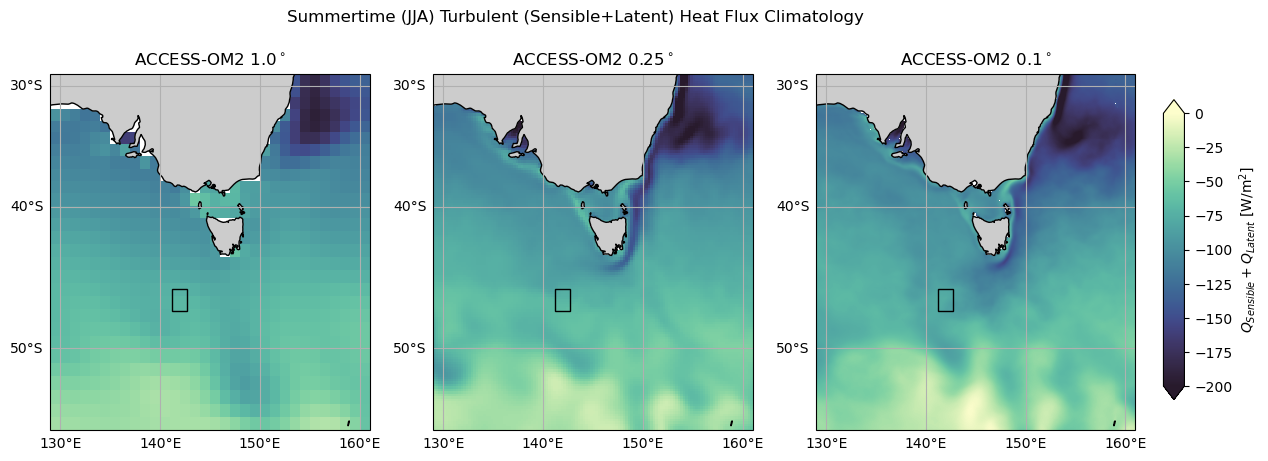

In [14]:
# --- wintertime turbulent (sensible + latent) heat fluxes
# Figure
fig, axes = plt.subplots(1, 3, figsize=(14, 5), subplot_kw={"projection": projection},)

turb010 = sensible010+latent010 
turb025 = sensible025+latent025
turb100 = sensible100+latent100

vmin = -200
vmax = 0

im0 = turb100.plot(ax = axes[0], transform=ccrs.PlateCarree(),
         vmin=vmin, vmax=vmax, cmap=cmo.cm.deep_r, add_colorbar=False)

im1 = turb025.plot(ax = axes[1], transform=ccrs.PlateCarree(),
         vmin=vmin, vmax=vmax, cmap=cmo.cm.deep_r, add_colorbar=False)

im2 = turb010.plot(ax = axes[2], transform=ccrs.PlateCarree(),
         vmin=vmin, vmax=vmax, cmap=cmo.cm.deep_r, add_colorbar=False)

cax = fig.add_axes([0.92, 0.2, 0.015, 0.6]) 
cbar = fig.colorbar(im2, cax=cax, orientation="vertical", label = r"$Q_{Sensible}+Q_{Latent}$ [W/m$^2$]", 
                    fraction = 0.03, aspect = 15,  shrink = 0.9, extend = "both")

#axes[2].contour(turb010['xt_ocean'], turb010['yt_ocean'], turb010, levels = [0], colors = 'k', transform=ccrs.PlateCarree(),)


titles = [r"ACCESS-OM2 $1.0^\circ$", r"ACCESS-OM2 $0.25^\circ$", r"ACCESS-OM2 $0.1^\circ$"]

for ax, title in zip(axes, titles):

    ax.set_extent([129, 161, -55, -29], crs=ccrs.PlateCarree())
    ax.add_feature(land_50m, color=[0.8, 0.8, 0.8])
    ax.coastlines(resolution="50m")
    ax.gridlines(draw_labels={"bottom": True, "left": True, "top": False, "right": False},
                 xlocs=[130, 140, 150, 160], ylocs=[-30, -40, -50],)

    rect = Rectangle(
            (inset_lon.min(), inset_lat.min()),
            np.diff(inset_lon)[0], np.diff(inset_lat)[0],
            linewidth=1, edgecolor='k', facecolor='none', linestyle='-',
            zorder=5, transform=ccrs.PlateCarree(),
        )
    
    ax.add_patch(rect,)
    ax.set_title(title)

plt.suptitle('Summertime (JJA) Turbulent (Sensible+Latent) Heat Flux Climatology')
plt.savefig("Qturb_summer_3panel.png", dpi=300, bbox_inches="tight")
# plt.show()